In [14]:
import pandas as pd
import seaborn as sns

In [20]:
def choose_best_gor(path, sample):
    df = pd.read_table(f"{path}/{sample}.txt")
    gors = list(df['FASTA ID'].unique())

    best_gors = []

    for gor in gors:
        gor_mask = df['FASTA ID'] == gor
        best_gors.append(df.loc[gor_mask].sort_values(by='MotifScore', ascending=False).iloc[0])

    toReturn = pd.DataFrame(best_gors)
    toReturn.to_csv(f"{path}/{sample}_highestScore.txt", sep='\t')
    return toReturn['MotifScore']

    

In [21]:
samples=[
    'overlapping_GORS_GCR_scores', 
    'overlapping_GORS_GCR_scores_A549',
    'overlapping_GORS_GCR_scores_U2OS'
]

path = '../../figure_outputs'

results = {}

for sample in samples:
    results[sample] = choose_best_gor(path, sample)

overlapping_GORS_GCR_scores
overlapping_GORS_GCR_scores_A549
overlapping_GORS_GCR_scores_U2OS


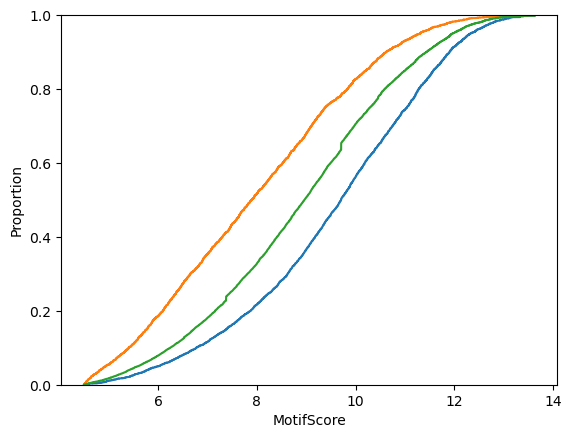

In [23]:
for sample in samples:
    print(sample)
    sns.ecdfplot(results[sample])